# Cross-dataset trait coverage comparison

**Environment:** `clamp-analyses`

Compares PhenomeXcan trait coverage across three full CLAMP models. Coverage is the proportion of all 4,049 PhenomeXcan traits significantly associated with at least one LV at FDR < 0.05.
- **GTEx**: `output/01_model_building/02_gtex/01_CLAMP/gls-summary-phenomexcan.tsv.gz`
- **recount2**: `output/01_model_building/03_recount2/00_recount2/gls-summary-phenomexcan.tsv.gz`
- **ARCHS4**: `output/01_model_building/04_archs4/06_bp_coverage_rshall/06_bp_coverage_hall_rs_100/hall_coverage_rs100_seed_1/gls-summary-phenomexcan.tsv.gz`

In [1]:
library(here)
library(ggplot2)
library(dplyr)
library(readr)

theme_ng <- function() {
  theme_classic(base_size = 18) +
    theme(
      axis.title = element_text(size = 24, colour = "black"),
      axis.title.y = element_text(margin = margin(r = 18)),
      axis.text = element_text(size = 18, colour = "black"),
      axis.line = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks = element_line(linewidth = 0.8, colour = "black"),
      axis.ticks.length = grid::unit(0.22, "cm"),
      panel.grid.major.y = element_line(colour = "#BDBDBD", linewidth = 0.7),
      panel.grid.minor = element_blank(),
      legend.position = "right",
      legend.title = element_text(size = 18),
      legend.text = element_text(size = 16),
      plot.title = element_blank(),
      strip.background = element_blank(),
      strip.text = element_text(face = "bold", size = 18),
      plot.margin = margin(t = 16, r = 12, b = 12, l = 42)
    )
}

here() starts at /home/msubirana/Documents/pivlab/clamp-analyses




Attaching package: ‘dplyr’




The following objects are masked from ‘package:stats’:

    filter, lag




The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## Load summaries and compute coverage

In [2]:
GetSampleCount <- function(sample_path, sample_field = NULL) {
  x <- readRDS(here(sample_path))
  if (!is.null(sample_field)) {
    return(as.integer(x[[sample_field]]))
  }
  as.integer(length(x))
}

GetTraitCoverage <- function(spec, total_traits, fdr.cutoff = 0.05) {
  path <- here(spec$path)
  if (!file.exists(path)) {
    stop("File not found: ", path)
  }

  summary_df <- readr::read_tsv(path, show_col_types = FALSE, progress = FALSE)
  expected_cols <- c("phenotype", "phenotype_desc", "lv", "pvalue", "fdr")
  if (!all(expected_cols %in% colnames(summary_df))) {
    stop("Unexpected columns in ", path, ": ", paste(colnames(summary_df), collapse = ", "))
  }

  sig_df <- summary_df %>%
    dplyr::filter(fdr < fdr.cutoff)

  n_phenotypes <- total_traits
  n_lvs        <- dplyr::n_distinct(summary_df$lv)
  n_sig_traits <- dplyr::n_distinct(sig_df$phenotype)
  n_sig_lvs    <- dplyr::n_distinct(sig_df$lv)

  data.frame(
    dataset       = spec$dataset,
    n_samples     = spec$n_samples,
    n_rows        = nrow(summary_df),
    n_sig_rows    = nrow(sig_df),
    n_phenotypes  = n_phenotypes,
    n_lvs         = n_lvs,
    n_sig_traits  = n_sig_traits,
    n_sig_lvs     = n_sig_lvs,
    prop_trait    = n_sig_traits / total_traits,
    prop_lv       = n_sig_lvs / n_lvs,
    nominal_n_lvs = n_lvs,
    path          = spec$path,
    stringsAsFactors = FALSE
  )
}

FDR_CUTOFF <- 0.05
PHENOMEXCAN_TOTAL_TRAITS <- 4049

model_list <- list(
  list(
    dataset   = "GTEx",
    path      = "output/01_model_building/02_gtex/01_CLAMP/gls-summary-phenomexcan.tsv.gz",
    n_samples = GetSampleCount("output/01_model_building/02_gtex/01_CLAMP/gtex_samples.rds")
  ),
  list(
    dataset   = "recount2",
    path      = "output/01_model_building/03_recount2/00_recount2/gls-summary-phenomexcan.tsv.gz",
    n_samples = GetSampleCount("output/01_model_building/03_recount2/00_recount2/recount2_samples.rds")
  ),
  list(
    dataset   = "ARCHS4",
    path      = "output/01_model_building/04_archs4/06_bp_coverage_rshall/06_bp_coverage_hall_rs_100/hall_coverage_rs100_seed_1/gls-summary-phenomexcan.tsv.gz",
    n_samples = GetSampleCount("output/01_model_building/04_archs4/01_archs4_preprocess/metadata_filtered.rds", "n_samples")
  )
)

results <- lapply(model_list, GetTraitCoverage,
                  total_traits = PHENOMEXCAN_TOTAL_TRAITS,
                  fdr.cutoff = FDR_CUTOFF)
results_df <- do.call(rbind, results)
results_df$dataset <- factor(results_df$dataset, levels = c("GTEx", "recount2", "ARCHS4"))
results_df <- results_df %>% dplyr::arrange(dataset)
rownames(results_df) <- NULL

stopifnot(nrow(results_df) == 3)
stopifnot(all(c("GTEx", "recount2", "ARCHS4") %in% as.character(results_df$dataset)))
stopifnot(all(results_df$n_sig_traits <= results_df$n_phenotypes))
stopifnot(all(results_df$n_sig_lvs <= results_df$n_lvs))
stopifnot(all(results_df$prop_trait >= 0 & results_df$prop_trait <= 1))
stopifnot(all(results_df$prop_lv >= 0 & results_df$prop_lv <= 1))

message(sprintf("FDR < %.2f", FDR_CUTOFF))
print(results_df)

FDR < 0.05



   dataset n_samples  n_rows n_sig_rows n_phenotypes n_lvs n_sig_traits
1     GTEx     17382 2340322       2837         4049   578          791
2 recount2     37032 3256750       4099         4049   875         1380
3   ARCHS4    605614 6996672       6889         4049  1728         1462
  n_sig_lvs prop_trait   prop_lv nominal_n_lvs
1       447  0.1953569 0.7733564           578
2       741  0.3408249 0.8468571           875
3      1253  0.3610768 0.7251157          1728
                                                                                                                                           path
1                                                                      output/01_model_building/02_gtex/01_CLAMP/gls-summary-phenomexcan.tsv.gz
2                                                               output/01_model_building/03_recount2/00_recount2/gls-summary-phenomexcan.tsv.gz
3 output/01_model_building/04_archs4/06_bp_coverage_rshall/06_bp_coverage_hall_rs_100/hall_c

## Plots

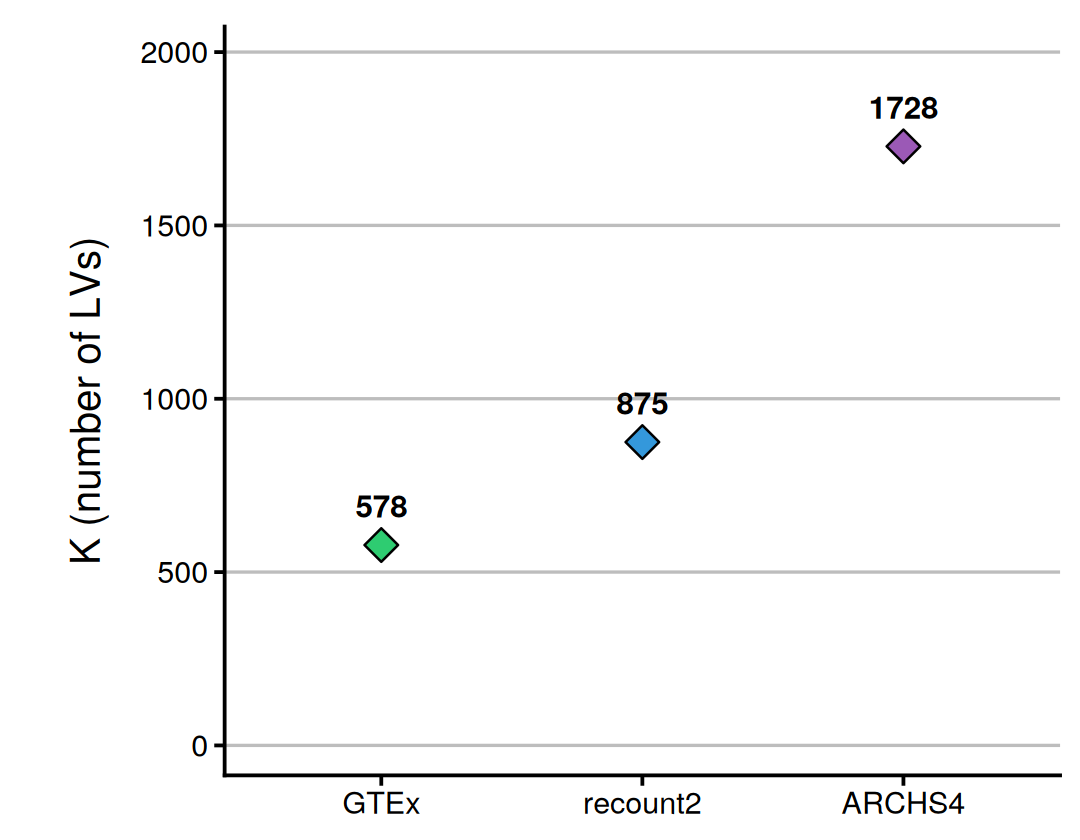

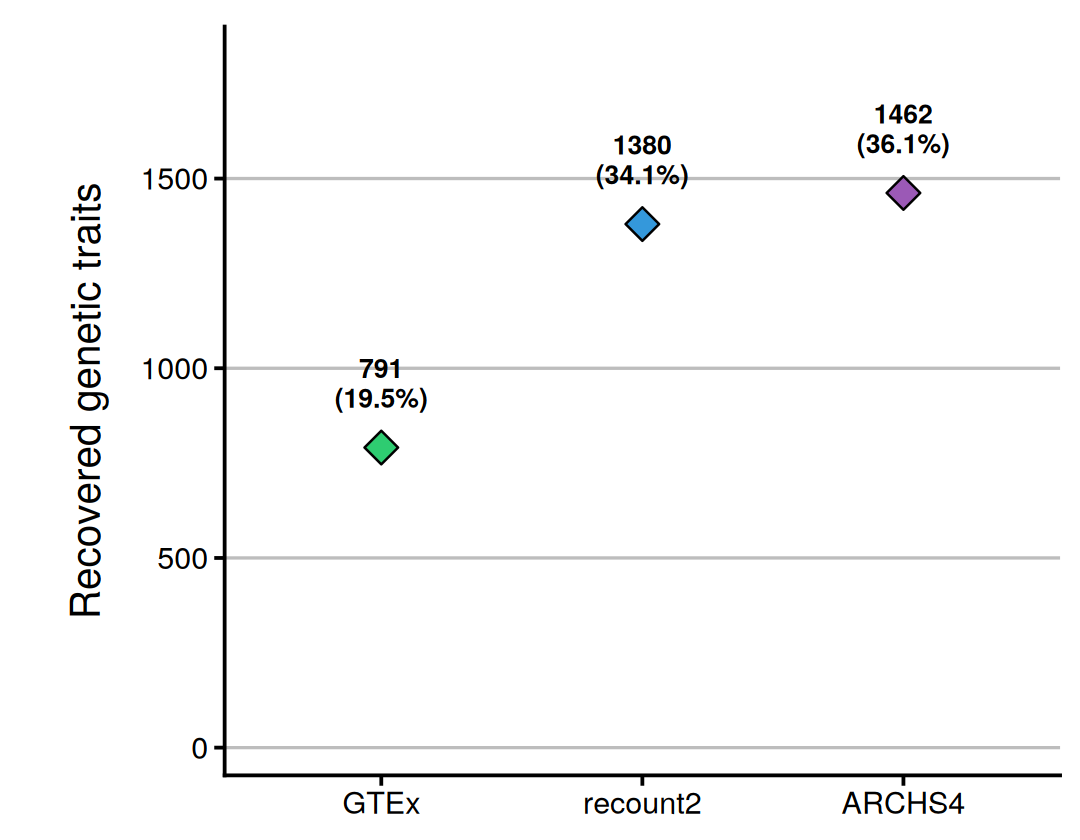

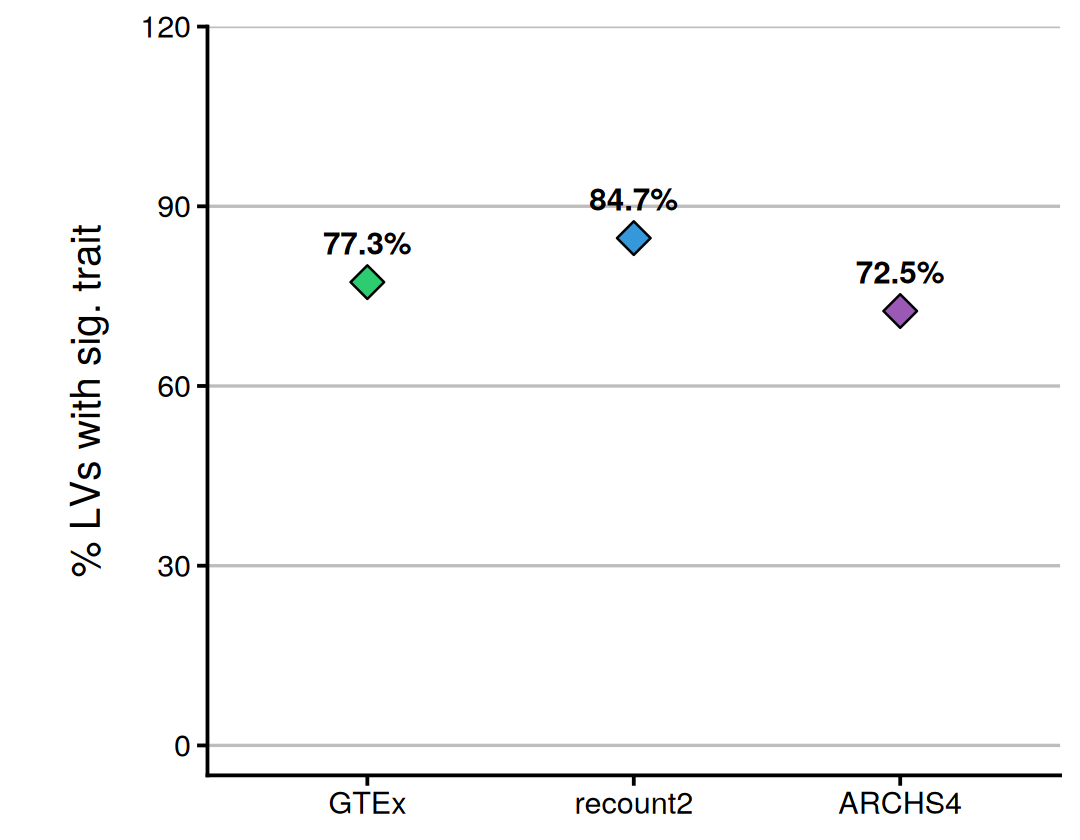

In [3]:
options(repr.plot.width = 9, repr.plot.height = 7)

dataset_colors <- c(
  ARCHS4   = "#9b59b6",
  recount2 = "#3498db",
  GTEx     = "#2ecc71"
)

p_lvs <- ggplot(results_df, aes(x = dataset, y = n_lvs, fill = dataset)) +
  geom_point(shape = 23, size = 7, colour = "black", stroke = 0.8) +
  geom_text(aes(label = n_lvs), vjust = -1.2, size = 6.5, fontface = "bold") +
  scale_fill_manual(values = dataset_colors, guide = "none") +
  scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0.05, 0.20))) +
  labs(x = NULL, y = "K (number of LVs)") +
  theme_ng() +
  theme(legend.position = "none")

p_ntraits <- ggplot(results_df, aes(x = dataset, y = n_sig_traits, fill = dataset)) +
  geom_point(shape = 23, size = 7, colour = "black", stroke = 0.8) +
  geom_text(
    aes(label = paste0(n_sig_traits, "\n(", sprintf("%.1f%%", prop_trait * 100), ")")),
    vjust = -0.8, size = 5.5, fontface = "bold", lineheight = 0.95
  ) +
  scale_fill_manual(values = dataset_colors, guide = "none") +
  scale_y_continuous(limits = c(0, NA), expand = expansion(mult = c(0.05, 0.30))) +
  labs(x = NULL, y = "Recovered genetic traits") +
  theme_ng() +
  theme(legend.position = "none")

p_prop_lv <- ggplot(results_df, aes(x = dataset, y = prop_lv * 100, fill = dataset)) +
  geom_point(shape = 23, size = 7, colour = "black", stroke = 0.8) +
  geom_text(aes(label = sprintf("%.1f%%", prop_lv * 100)), vjust = -1.2, size = 6.5, fontface = "bold") +
  scale_fill_manual(values = dataset_colors, guide = "none") +
  scale_y_continuous(limits = c(0, 100), expand = expansion(mult = c(0.05, 0.20))) +
  labs(x = NULL, y = "% LVs with sig. trait") +
  theme_ng() +
  theme(legend.position = "none")

p_lvs
p_ntraits
p_prop_lv

In [4]:
options(repr.plot.width = 13, repr.plot.height = 7)

summary_long <- results_df %>%
  dplyr::mutate(
    n_samples_fmt = format(n_samples, big.mark = ","),
    prop_trait_fmt = sprintf("%.1f%%", prop_trait * 100),
    prop_lv_fmt    = sprintf("%.1f%%", prop_lv * 100)
  ) %>%
  dplyr::select(dataset, n_samples_fmt, n_lvs, n_phenotypes, n_sig_traits, prop_trait_fmt, prop_lv_fmt)

colnames(summary_long) <- c("Dataset", "Samples", "K (LVs)", "Input traits", "Sig. traits", "% traits", "% LVs")

print(summary_long, row.names = FALSE)

  Dataset Samples K (LVs) Input traits Sig. traits % traits % LVs
     GTEx  17,382     578         4049         791    19.5% 77.3%
 recount2  37,032     875         4049        1380    34.1% 84.7%
   ARCHS4 605,614    1728         4049        1462    36.1% 72.5%


## Export for Figure 4

In [5]:
PANEL_DIR_FIG4 <- here("output/99_panels/fig4")
dir.create(PANEL_DIR_FIG4, recursive = TRUE, showWarnings = FALSE)

export_df <- results_df %>%
  dplyr::select(n_rows, n_sig_rows, n_phenotypes, n_lvs, n_sig_traits,
                n_sig_lvs, prop_trait, prop_lv, dataset, n_samples,
                nominal_n_lvs, path)

write.csv(export_df, file.path(PANEL_DIR_FIG4, "trait_model_coverage_seed1.csv"), row.names = FALSE)
message("Saved trait_model_coverage_seed1.csv to ", PANEL_DIR_FIG4)

Saved trait_model_coverage_seed1.csv to /home/msubirana/Documents/pivlab/clamp-analyses/output/99_panels/fig4

